# Subsampling

This notebook addresses subsampling, which aims to **reduce the size of pointclouds to enable more efficient processing**. Indeed, real-world pointclouds often consist of millions of points, if not more. However, much of this information is redundant, as neighboring points often carry very similar geometric details. This redundancy means that it is often possible to significantly reduce the number of points **while preserving the essential structure and features of the underlying scene or object**.

This notebook focuses on some of the most used subsampling methods, which are classified into the following categories: index-based, spatial partitioning and distance-based. Popular techniques are discussed for each category. A quick comparison between these methods and techniques is proposed at the end.

Note that implementations return indices of sampled points (instead of coordinates) to be more memory‑efficient, preserve access to all original attributes (e.g., normals or colors), and better compose with other operations.

In [1]:
# Necessary imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

# Load our bunny pointcloud
points = np.loadtxt("./data/stanford_bunny_simple.xyz")
kdtree = KDTree(points)

## Index-based

Index‑based subsampling selects points using only their indices or ordering, without explicitly considering the underlying geometry. These techniques are both simple and fast. However, spatial uniformity and coverage are not guaranteed, which impacts the preservation of critical details, especially in non‑uniformly sampled pointclouds. Because of these limitations, these techniques are usually used as baselines in benchmarks or for visualization purposes.

### Random Sampling

Random sampling is one of the simplest subsampling techniques. It works by **selecting a subset of points at random from the original pointcloud**, either by specifying a fixed number of points $k$ or a fixed sampling ratio. By default, all points are assigned the same selection probability, and each point can be selected at most once. 

The simplest implementation relies on randomly permuting point indices and retaining the first $k$ elements. An alternative approach is *Bernoulli* (probability‑based) sampling, where an independent random number is drawn for each point and the point is kept if this value is below a user‑defined threshold $p$. Note that, in this case, the resulting sample size is random and has an expected value of approximately $pn$, where $n$ is the initial number of points. Large or streaming pointclouds commonly use a technique called *reservoir sampling*, which allows a fixed‑size random subset to be selected in a single pass without requiring the entire pointcloud to be stored in memory (more details can be found in the original paper: Vitter, J. S. (1985). Random sampling with a reservoir. *ACM Transactions on Mathematical Software (TOMS)*, 11(1), 37-57.).

The implementation below follows a simple strategy that generates $k$ random indices.

In [2]:
def random_sampling(points, num_samples):
    """Randomly samples a subset of points from the pointcloud."""

    N, _ = points.shape
    if num_samples >= N:
        raise ValueError("num_samples must be less than the total number of points.")
    # Create a random number generator to draw samples
    rng = np.random.default_rng()
    
    return rng.choice(N, num_samples, replace=False)


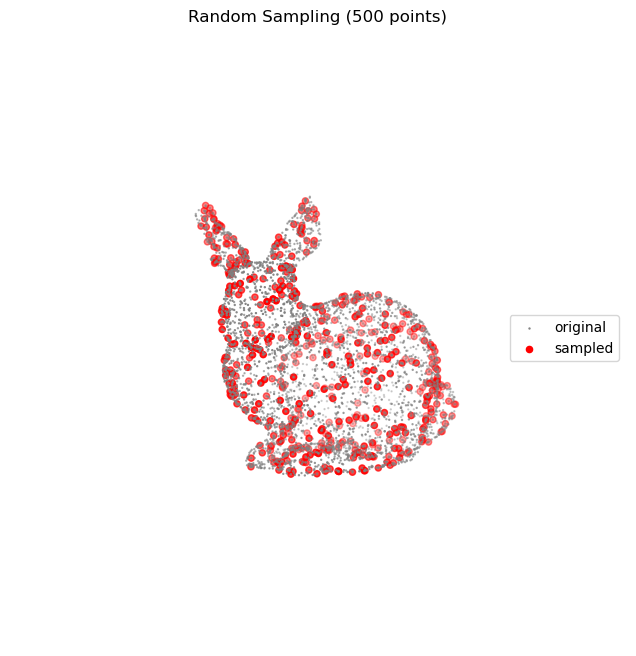

In [3]:
# Randomly sample 500 points from the bunny pointcloud
random_sampled_indices = random_sampling(points, 500)
random_sampled_points = points[random_sampled_indices]

# Visualize the original and randomly sampled pointclouds
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           color='grey', s=0.5, label='original')
ax.scatter(random_sampled_points[:, 0], random_sampled_points[:, 1],
            random_sampled_points[:, 2], 
            color='red', label="sampled")
ax.set_title(f"Random Sampling ({len(random_sampled_points)} points)")
ax.legend(loc="right")
ax.view_init(10, 60)
ax.set_axis_off()
plt.axis("equal")
plt.show()

### Stride Sampling

Stride Sampling, sometimes called uniform sampling, is a simple and fast technique that works by **selecting points at regular index intervals**. Unlike random sampling, it is deterministic and therefore reproducible. Although it does not explicitly enforce spatial constraints, it may preserve approximate spatial uniformity when the point ordering reflects spatial locality, as is often the case for sequential acquisition systems such as RGB‑D cameras or linear laser scanners. However, when this assumption does not hold, uniform sampling may introduce strong spatial bias.

Implementation is straightforward and simply amounts to keeping every $n$-th point according to the initial ordering.

The implementation below uses NumPy's *slicing*, with an option to modify the initial ordering to add some randomness.

In [4]:
def uniform_sampling(points, stride, shuffle=False):
    """Uniformly samples points from the pointcloud using a given stride."""
    
    N, _ = points.shape
    if not (isinstance(stride, int) and 1 <= stride < N):
        raise ValueError("stride must be an integer >= 1 and less than the total number of points.")
    indices = np.arange(N)
    # Optionally shuffle the pointcloud to avoid bias
    if shuffle:
        np.random.shuffle(indices)
    
    return indices[::stride]


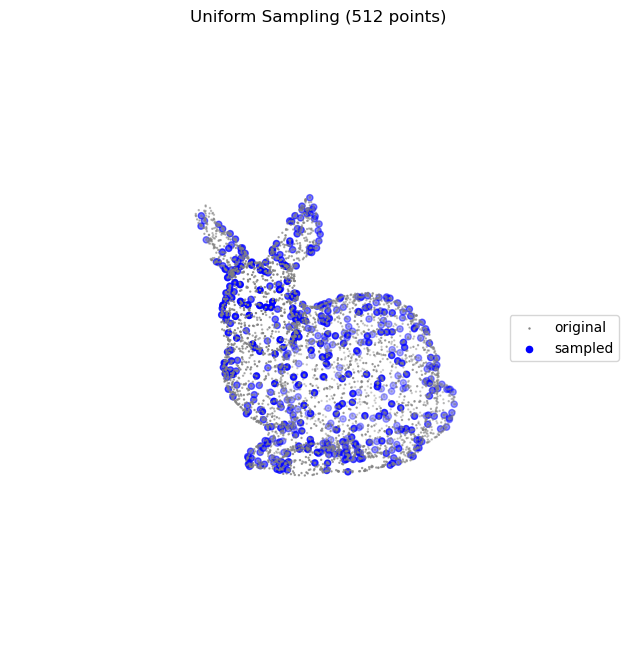

In [ ]:
# Uniformly sample points from the bunny pointcloud with a stride of 8 (to have a similar number of points as before)
uniform_sampled_indices = uniform_sampling(points, stride=8)
uniform_sampled_points = points[uniform_sampled_indices]

# Visualize the original and uniformly sampled pointclouds
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           color='grey', s=0.5, label='original')
ax.scatter(uniform_sampled_points[:, 0], uniform_sampled_points[:, 1],
            uniform_sampled_points[:, 2], 
            color='blue', label="sampled")
ax.set_title(f"Stride Sampling ({len(uniform_sampled_points)} points)")
ax.legend(loc="right")
ax.view_init(10, 60)
ax.set_axis_off()
plt.axis("equal")
plt.show()

## Spatial partitioning

Spatial partitioning divides three-dimensional space into "regions", more practically implemented as regularly spaced, axis-aligned cubic or cuboidal cells that contain subsets of points (see the notebook on spatial indexing). The core idea here is to **select one or more points from each cell**. By enforcing a more uniform spatial distribution of points, this approach tends to preserve the global structure of the initial pointcloud better than index-based methods. As a result, it is widely used in practice when uniform coverage is required. Note, however that as spatial structures are axis-aligned they may introduce discretization artifacts. Note also that spatial structures are often built beforehand to support operations such as nearest-neighbor search, which makes it possible to reuse them for downsampling at little additional cost.

Also note that it is possible to replace all points in a cell with a single representative point (often the centroid), but this differs from simple subsampling, as it modifies point locations rather than selecting existing ones.

Spatial partitioning techniques are categorized according to the underlying spatial structure: a uniform grid with *voxel grid downsampling* and a hierarchical grid with *octree downsampling*. Note that kd‑trees are not considered here, since their partitioning is irregular and unrelated to geometric scale, making them quite unsuitable for subsampling tasks.

### Voxel Grid Downsampling

Voxel grid downsampling operates by **partitioning space into a regular grid of voxels and selecting one or more representative point per voxel**. The voxel size is specified upfront and directly controls both the spatial resolution and coverage of the subsampled pointcloud. This makes voxel grid downsampling (and other operations) **particularly suitable when the desired resolution is known in advance**. When the desired resolution is not a priori known, a trade‑off must be established between geometric detail preservation and point count reduction, often by evaluating several voxel sizes. Once the voxel grid has been constructed, the downsampling process is computationally efficient, as it reduces to an independent selection operation performed once per occupied voxel.

Several strategies exist for choosing the representative point within each voxel. The most straightforward approaches consist of retaining the first point encountered or selecting a point at random. These strategies are conceptually close to index‑based random sampling, with the addition of a weak spatial regularization imposed by the voxel structure. More popular alternatives select the point closest to the voxel center or to the voxel centroid, which tends to better preserve the spatial distribution of the original pointcloud.

A custom voxel grid implementation based on a dictionary (hash map) is presented below, with options to retain either the first point stored in each voxel or the point closest to the voxel center.

In [6]:
class VoxelGrid:
    """Regular 3D grid to partition a pointcloud into cubic voxels."""

    class Voxel:
        """A single voxel cell in the voxel grid."""

        def __init__(self, coord):
            self.coord = coord
            self.point_indices = []

        def add_point(self, point_index):
            """Add a point index to this voxel."""
            
            self.point_indices.append(point_index)

    def __init__(self, points, voxel_size):
        
        self.points = points
        self.voxel_size = voxel_size
        self._voxels = {}
        self._build_voxel_grid()

    def _build_voxel_grid(self):
        """Create the voxel grid by filling cells with points."""
        
        # Associate each point to a cell
        point_voxel = (self.points//self.voxel_size).astype(int)
        # Create a dict with {coord:voxel}
        for point_index, voxel_coord in enumerate(point_voxel): 
            # Create the voxel if it does not already exist
            coord = tuple(voxel_coord.tolist())
            voxel = self._voxels.setdefault(coord, VoxelGrid.Voxel(coord))
            # Store point index in the voxel
            voxel.add_point(point_index)

    def sample_points(self, closest_to_center=False):
        """Sample one index per voxel, either the first point or the one closest to the voxel center."""
        
        sampled_indices = []
        for voxel in self._voxels.values():
            if closest_to_center:
                # Compute voxel center (suppose no offset)
                voxel_center = (np.array(voxel.coord) + 0.5) * self.voxel_size
                # Find the point in the voxel closest to the voxel center
                points_in_voxel = self.points[voxel.point_indices]
                # (Optionally use squared distances for efficiency)
                distances = np.linalg.norm(points_in_voxel - voxel_center, axis=1)
                closest_point_idx = np.argmin(distances)
                chosen_index = voxel.point_indices[closest_point_idx]
            else:
                chosen_index = voxel.point_indices[0]
            sampled_indices.append(chosen_index)
        
        return sampled_indices


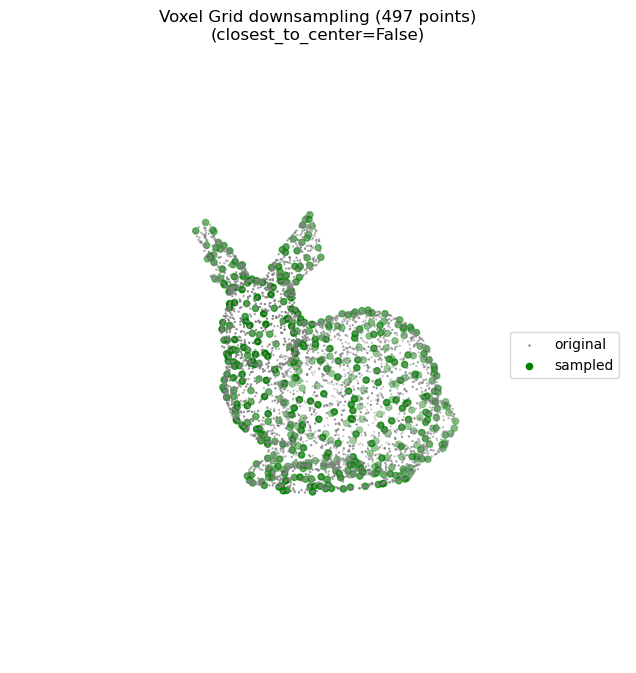

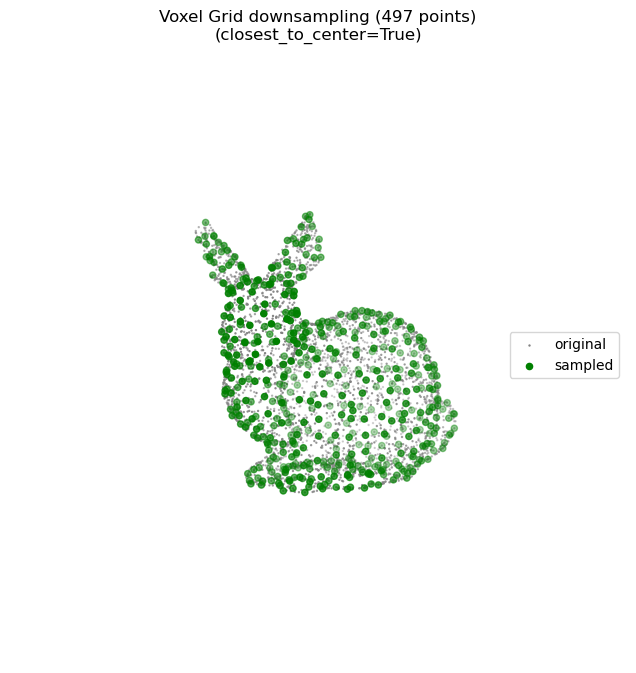

In [7]:
# Voxel grid downsampling
voxel_grid = VoxelGrid(points, voxel_size=12.) # Adjust voxel size to get a similar number of points as before
# Try both sampling methods: first point and closest to center
for closest_to_center in [False, True]:
    sampled_indices = VoxelGrid.sample_points(voxel_grid, closest_to_center)
    voxel_sampled_points = points[sampled_indices]

    # Visualize the original and voxel grid downsampled pointclouds
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2],
            color='grey', s=0.5, label='original')
    ax.scatter(voxel_sampled_points[:, 0], voxel_sampled_points[:, 1],
            voxel_sampled_points[:, 2], color='green', label="sampled")
    ax.set_title(f"Voxel Grid downsampling ({len(voxel_sampled_points)} points)\n(closest_to_center={closest_to_center})")
    ax.legend(loc="right")
    ax.view_init(10, 60)
    ax.set_axis_off()
    plt.axis("equal")
    plt.show()

### Octree Downsampling

Octree downsampling follows similar principles to voxel grid downsampling but relies on a hierarchical spatial subdivision rather than a regular grid. This hierarchical construction allows the octree to adapt naturally to the spatial distribution of the points, as regions with high point density are subdivided more finely. This makes octree downsampling particularly **well suited to situations where the appropriate level of detail is unknown in advance or where the point density is highly non‑uniform**. This adaptability comes at the cost of a more complex data structure and a higher construction overhead compared to voxel grids. However, once the octree has been constructed, the subsampling scale can be adjusted efficiently operating at different depths of the tree, without requiring a full reconstruction. 

As with voxel grids, representative points may be chosen using simple strategies such as retaining the first point or selecting one at random or using more geometry‑aware criteria such as proximity to the leaf center or centroid. Note that, since point occupancy varies across octree levels, the final number of points at any chosen depth cannot be precisely controlled.

The custom octree implementation presented below simply selects the first point of the node at a given subdivision level.

In [8]:
class OcTree:
    """Partition 3D space by recursively subdividing it into eight octants."""
    
    class OctNode:
        """A node of our Octree or octant."""

        def __init__(self, depth, bound_min, bound_max, indices):

            self.depth = depth # Distance of this node from the root
            self.bound_min = bound_min # Position of bottom-left corner
            self.bound_max = bound_max # Position of top-right corner
            self.indices = indices # Store point indices instead of coordinates
            self.children = [] # Assume terminal node by default

        @property
        def is_leafnode(self):
            """A terminal/leaf node does not have children."""

            return not len(self.children)

    def __init__(self, points, leafsize=10, max_depth=10):

        self.points = points
        self.leafsize = leafsize
        self.max_depth = max_depth
        # Create root node
        bound_min = points.min(axis=0)
        bound_max = points.max(axis=0)
        indices = np.arange(len(points), dtype=int)
        self.root = OcTree.OctNode(0, bound_min, bound_max, indices)
        # Recursively build the tree
        self._split_node(self.root)
    
    def _split_node(self, node):
        """Recursively split a node into eight subnodes/children."""

        # Do not split if node is already too small or if reached the maximum depth
        if len(node.indices) < self.leafsize or node.depth >= self.max_depth:
            return
        # Compute the bounds of the four candidate subnodes
        x_center, y_center, z_center = (node.bound_min + node.bound_max)/2
        x_min, y_min, z_min = node.bound_min
        x_max, y_max, z_max = node.bound_max
        new_bounds = [ 
            # South-West-Back
            (np.array([x_min, y_min, z_min]), np.array([x_center, y_center, z_center])),
            # North-West-Back
            (np.array([x_min, y_min, z_center]), np.array([x_center, y_center, z_max])),
            # Nord-East-Back
            (np.array([x_min, y_center, z_center]), np.array([x_center, y_max, z_max])),
            # South-East-Back
            (np.array([x_min, y_center, z_min]), np.array([x_center, y_max, z_center])),
            # South-West-Front
            (np.array([x_center, y_min, z_min]), np.array([x_max, y_center, z_center])),
            # North-West-Front
            (np.array([x_center, y_min, z_center]), np.array([x_max, y_center, z_max])),
            # Nord-East-Front
            (np.array([x_center, y_center, z_center]), np.array([x_max, y_max, z_max])),
            # South-East-Front
            (np.array([x_center, y_center, z_min]), np.array([x_max, y_max, z_center]))
        ]
        # Compute the node points falling into each subnode
        for (bound_min_new, bound_max_new) in new_bounds:
            in_subnode = np.logical_and(
                (self.points[node.indices] >= bound_min_new).all(axis=1), 
                (self.points[node.indices] <= bound_max_new).all(axis=1)
            )
            # A subnode is created only if it contains some points
            if np.any(in_subnode):
                subnode = OcTree.OctNode(
                    node.depth + 1, # Increment depth
                    bound_min_new,
                    bound_max_new, 
                    node.indices[in_subnode]
                )
                node.children.append(subnode)
                # Split this subnode further (until children are too small)
                self._split_node(subnode)
        # Clear node indices after the node is split (only store them for leaf nodes)
        node.indices = []
    
    def downsample(self, subdivision_level):
        """Select the first point per node at a given subdivision level
         (if exceeding the octree depth, it just samples from leaves)."""

        sampled_indices = []
        # Explore the tree using breadth-first search
        queue = [self.root]
        while queue:
            node = queue.pop(0)
            # Check if we reached the desired subdivision level
            if node.depth < subdivision_level and not node.is_leafnode:
                # If not, continue exploring the tree
                queue.extend(node.children)
            else:
                # Continue down to a leaf node via the first child
                while not node.is_leafnode:
                    node = node.children[0]
                # Sample the first points from this leaf node
                sampled_indices.append(node.indices[0])     

        return sampled_indices
    

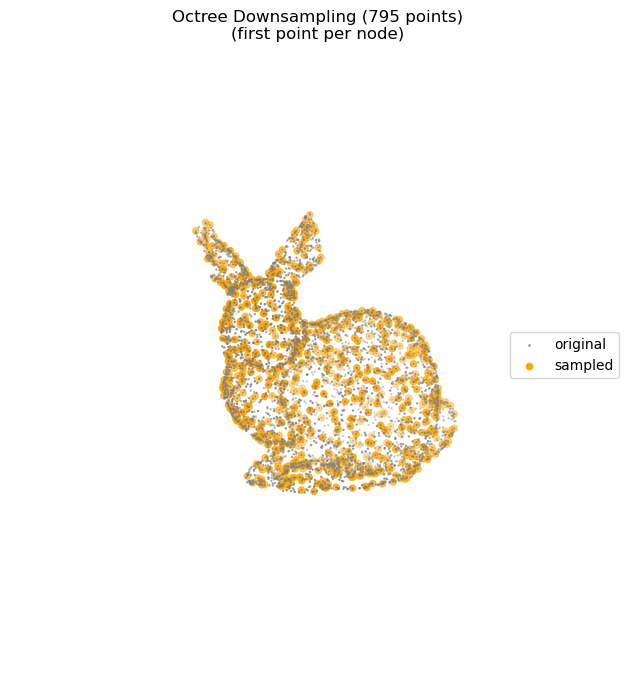

In [9]:
# Octree downsampling
octree = OcTree(points, leafsize=10)
sampled_indices = octree.downsample(subdivision_level=4) # Difficult to get a similar number of points as before
octree_sampled_points = points[sampled_indices]

# Visualize the original and octree downsampled pointclouds
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
              color='grey', s=0.5, label='original')
ax.scatter(octree_sampled_points[:, 0], octree_sampled_points[:, 1],
              octree_sampled_points[:, 2], color='orange', label="sampled")
ax.set_title(f"Octree Downsampling ({len(octree_sampled_points)} points)\n(first point per node)")
ax.legend(loc="right")
ax.view_init(10, 60)
ax.set_axis_off()
plt.axis("equal")
plt.show()

## Distance-based

Distance-based techniques rely on pairwise distances between points to guide subsampling. Spatial coverage and uniformity are preserved by avoiding the selection of points that are too close to each other.

### Farthest Point Sampling

Farthest Point Sampling (FPS) operates by **iteratively selecting the point that maximizes its distance to the current set of sampled points**, yielding a well‑distributed subset that provides good geometric coverage of the original pointcloud. The main limitation of FPS is its computational cost: at each iteration, distance evaluations must be performed for many points, which becomes expensive for large pointclouds.

A common practical optimization is to avoid recomputing distances from every unsampled point to all previously selected samples. Instead, only the current minimum distance to any selected point is stored for each point. At each iteration, only this value needs to be updated based on the latest selected point. Additionally, implementations often rely on squared Euclidean distances to avoid unnecessary square‑root operations while preserving distance ordering. This results in the classical naïve implementation of FPS, which, despite these optimizations, still requires updating distances for all remaining points at each iteration.

To mitigate this bottleneck, more advanced strategies rely on spatial data structures and localized search. A straightforward improvement consists of performing ball queries around the newly selected point, restricting updates to only those points whose current stored distance could potentially decrease. Although this provides limited speed‑up in the early stages (when the maximum distance is still large and most points remain eligible) the acceleration becomes increasingly substantial as the sampling progresses and the update region shrinks. Further performance gains can be achieved through techniques such as dual‑tree traversal and approximate nearest‑neighbor (ANN) search, which reduce the number of distance evaluations even more aggressively.

An implementation of FPS supporting both the naïve and spatial-structure accelerated techniques is proposed below.


In [10]:
def farthest_point_sampling(points, num_samples, neighbor_finding_function=None):
    """Farthest Point Sampling (FPS) algorithm."""
    
    N, _ = points.shape
    if num_samples >= N:
        raise ValueError("num_samples must be less than the total number of points.")
    
    # For the naive case, point and radius are unused and all points are considered
    if neighbor_finding_function is None:
        neighbor_finding_function = lambda point, radius:  np.arange(N)

    # Randomly select the first point
    first_index = np.random.randint(N)
    sampled_indices = np.empty(num_samples, dtype=int)
    sampled_indices[0] = first_index
    first_point = points[sampled_indices[0]] # first sampled point

    # Initialize distances
    squared_distances = np.sum((points - first_point) ** 2, axis=1)
    squared_distances[first_index] = 0.
        
    for i in range(1, num_samples):
        # Select the farthest point
        farthest_index = np.argmax(squared_distances)
        sampled_indices[i] = farthest_index
        farthest_point = points[farthest_index]

        # Compute radius to find points that need distance updates
        farthest_distance = squared_distances[farthest_index]
        radius = np.sqrt(farthest_distance)
        neighbor_indices = neighbor_finding_function(farthest_point, radius)

        # Update distances to the last sampled point
        dist_to_last = np.sum((points[neighbor_indices] - farthest_point) ** 2, axis=1)
        squared_distances[neighbor_indices] = np.minimum(squared_distances[neighbor_indices],
                                                         dist_to_last)
        squared_distances[farthest_index] = 0.0
    
    return sampled_indices


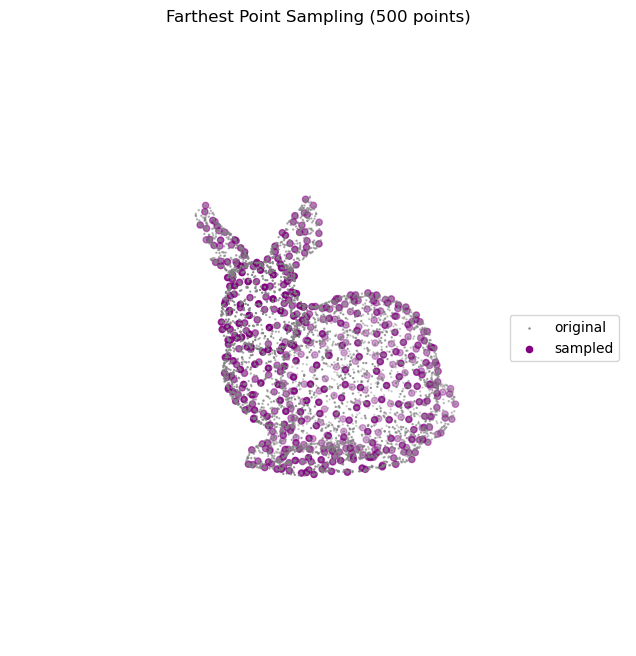

In [11]:
# Farthest Point Sampling of 500 points from the bunny pointcloud
neighbor_finding_function = lambda point, radius: kdtree.query_ball_point(point, radius)
fps_sampled_indices = farthest_point_sampling(points, 500, neighbor_finding_function)
fps_sampled_points = points[fps_sampled_indices]

# Visualize the original and FPS sampled pointclouds
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           color='grey', s=0.5, label='original')
ax.scatter(fps_sampled_points[:, 0], fps_sampled_points[:, 1], fps_sampled_points[:, 2], 
           color='purple', label="sampled")
ax.set_title(f"Farthest Point Sampling ({len(fps_sampled_points)} points)")
ax.legend(loc="right")
ax.view_init(10, 60)
ax.set_axis_off()
plt.axis("equal")
plt.show()

### Radius Sampling

Radius sampling (also called minimum‑distance sampling) **selects points such that no two retained points lie within a distance $r$ of each other**, enforcing a spatial separation constraint through a greedy approach. Points are processed in a chosen order, and once a point is accepted, all other points within radius $r$ are excluded from further consideration. This guarantees that the resulting set has a minimum inter‑point spacing of at least $r$. The approach is deterministic for a fixed ordering and radius.

Efficient implementation relies on spatial search structures to quickly identify neighbors within the radius $r$. For example, CloudCompare uses an octree to accelerate these queries.

The implementation below instead relies on a kd‑tree for fast neighborhood searches and uses a Boolean mask to track already discarded points.

In [12]:
def spatial_sampling(points, neighbor_finding_function, shuffle=False):
    """Spatial sampling a with greedy algorithm producing a Poisson-like distribution."""

    N, _ = points.shape
    # Optionally shuffle the pointcloud to avoid bias
    order = np.arange(N)
    if shuffle:
        np.random.shuffle(order)
    
    sampled_indices = []
    discarded = np.zeros(N, dtype=bool)
    
    for ind in order:
        
        if not discarded[ind]:
            sampled_indices.append(ind)
            neighbors = neighbor_finding_function(points[ind])
            discarded[neighbors] = True

    return sampled_indices


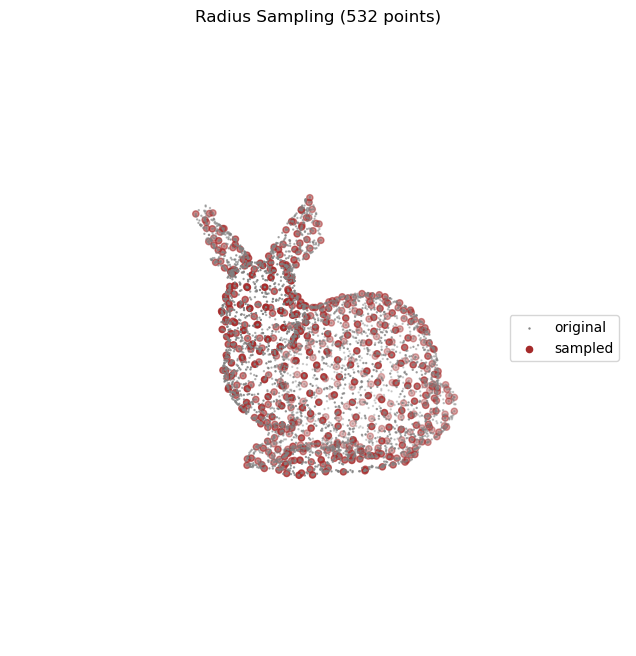

In [13]:
# Poisson Disk Sampling with greedy algorithm
neighbor_finding_function = lambda point: kdtree.query_ball_point(point, r=7.5) # Adjust radius to get a similar number of points as before
spatial_sampled_indices = spatial_sampling(points, neighbor_finding_function)
spatial_sampled_points = points[spatial_sampled_indices]

# Visualize the original and Poisson Disk sampled pointclouds
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           color='grey', s=0.5, label='original')
ax.scatter(spatial_sampled_points[:, 0], spatial_sampled_points[:, 1], spatial_sampled_points[:, 2],
              color='brown', label="sampled")
ax.set_title(f"Radius Sampling ({len(spatial_sampled_points)} points)")
ax.legend(loc="right")
ax.view_init(10, 60)
ax.set_axis_off()
plt.axis("equal")
plt.show()

### Poisson Disk Sampling

Poisson Disk Sampling (PDS) is a popular technique used in computer graphics and computational geometry for **generating** randomly distributed yet evenly spaced points. It enforces a minimum distance between sampled points while maintaining randomness (often referred to as "blue noise"), producing a uniform yet visually pleasing result. This concept has been adapted to 3D pointcloud subsampling with the aim of **selecting** points from an existing pointcloud with the same constraints as described before. This yields a uniform result while avoiding noticeable patterns often introduced by grid-based subsampling techniques.

One of the simplest and most popular techniques used to achieve a Poisson Disk Sampling distribution is called **Dart throwing**. The idea is to "throw darts" by **picking random points and accepting them only if they are at least a minimum distance $r$ away from all previously accepted points**. The "classic" sampling algorithm usually stops after a maximum number of attempts. Adapted to pointcloud subsampling, it simply iterates through existing points (in random order) instead of generating new ones. This is very similar to the *Radius Sampling* algorithm described before, only that point selection is always random.

Common implementations of dart throwing store accepted points in a voxel grid with cubic voxels of size $r/\sqrt{3}$ for fast neighbor checks. Indeed, making the voxel diagonal exactly $r$ guarantees that at most one point can lie in a voxel. So, any already accepted point potentially conflicting with the candidate point must lie in the candidate's voxel or one of its 26 neighbors. This greatly limits the number of voxels to check for each tentative.


In [14]:
def poisson_disk_dart_throwing(points, radius):
    """Adaptation of Dart Throwing on a 3D pointcloud."""

    N, _ = points.shape

    # Shuffle candidate order to mimic randomness of dart throwing
    rng = np.random.default_rng()
    order = rng.permutation(N)

    # Voxel grid to store already sampled/accepted points
    voxel_grid = {} # (coords to list of sampled/accepted point indices)
    # Cell size is chosen based on radius to optimize neighbor search
    cell_size = radius / np.sqrt(3.0)

    # Precompute voxel coords of all points to avoid recomputing repeatedly
    point_voxel_coords = np.floor(points / cell_size).astype(np.int64)

    # Neighbor cell offsets (3x3x3 cube)
    neighbor_offsets = np.array(
        [(dx, dy, dz) for dx in (-1, 0, 1)
                      for dy in (-1, 0, 1)
                      for dz in (-1, 0, 1)],
        dtype=np.int64
    )

    # Loop over points (in random order) so it stops when there are no more "darts" to throw
    for ind in order:
        candidate_point = points[ind]
        candidate_voxel = point_voxel_coords[ind]
        # Gather potential neighbors from current and adjacent voxels
        nearest_accepted_inds = []
        for off in neighbor_offsets:
            key = tuple((candidate_voxel + off).tolist())
            if key in voxel_grid:
                nearest_accepted_inds.extend(voxel_grid[key])

        # Check distances to nearest accepted points only
        if nearest_accepted_inds:
            nearest_accepted_points = points[np.array(nearest_accepted_inds)]
            dists = np.linalg.norm(nearest_accepted_points - candidate_point, axis=1)
            # Skip this candidate if too close to existing points
            if np.any(dists < radius):
                continue

        # Accept candidate point if not previously rejected
        key = tuple(candidate_voxel.tolist())
        if key not in voxel_grid:
            voxel_grid[key] = []
        voxel_grid[key].append(ind)

    return np.concatenate([*voxel_grid.values()], dtype=np.int64)


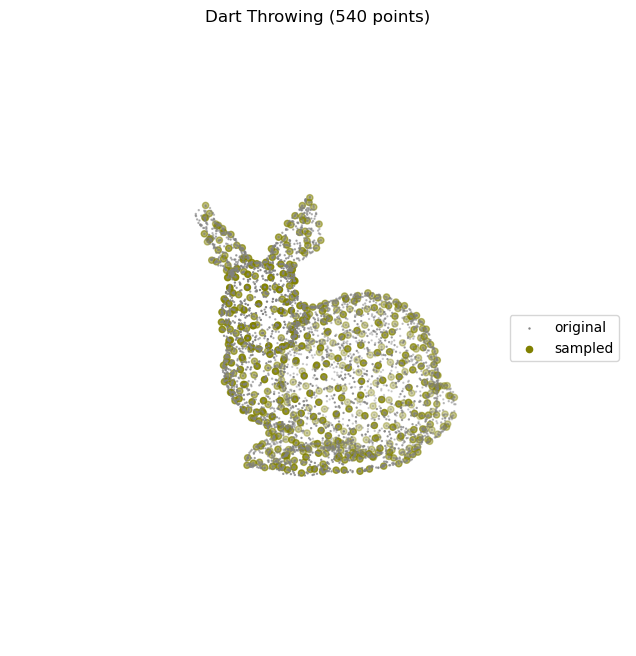

In [15]:
# Dart throwing
poisson_sampled_indices = poisson_disk_dart_throwing(points, radius=8.) # Adjust radius to get a similar number of points as before
poisson_sampled_points = points[poisson_sampled_indices]

# Visualize the original and Poisson Disk sampled pointclouds
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           color='grey', s=0.5, label='original')
ax.scatter(poisson_sampled_points[:, 0], poisson_sampled_points[:, 1],
           poisson_sampled_points[:, 2],
              color='olive', label="sampled")
ax.set_title(f"Dart Throwing ({len(poisson_sampled_points)} points)")
ax.legend(loc="right")
ax.view_init(10, 60)
ax.set_axis_off()
plt.axis("equal")
plt.show()


More efficient variants of Poisson disk sampling have been proposed to overcome the high rejection rates of classic dart‑throwing methods. A widely used improvement is **Bridson's Poisson Disk Sampling**, introduced in: Bridson, R. (2007), "Fast Poisson disk sampling in arbitrary dimensions", In *SIGGRAPH Sketches*. The key idea is to **maintain an active list of sample points and generates candidate samples only within an annulus around each active point**, reducing wasted attempts. When adapted to subsampling, the algorithm operates on the set of input points by iteratively rejecting points that violate the minimum distance constraint, while using Bridson's active‑set strategy to guide the order in which candidates are evaluated.

Practical optimizations include limiting the number of candidate attempts per active point (commonly $k=30$) and relying on a background grid for fast distance checks.

Note that more advanced techniques also exist. For example, the `sample_points_poisson_disk` function in the `Open3D` library builds Poisson‑disk–like distributions through greedy sample elimination rather than sample selection, making it more suitable for subsampling existing discrete pointclouds. More details are given in: Yuksel, C. (2015). Sample elimination for generating Poisson disk sample sets. In *Computer Graphics Forum*.

In [18]:
def poisson_disk_subsample(points, neighbor_finding_function, radius, k=30):
    """Adaptation of Bridson's Poisson Disk Sampling on a 3D pointcloud."""

    N, _ = points.shape
    rng = np.random.default_rng()

    # Voxel grid for fast conflict checks
    cell_size = radius / np.sqrt(3.0)
    point_voxel = np.floor(points / cell_size).astype(np.int64)

    neighbor_offsets = np.array(
        [(dx, dy, dz) for dx in (-1, 0, 1)
                       for dy in (-1, 0, 1)
                       for dz in (-1, 0, 1)],
        dtype=np.int64
    )

    voxel_grid = {}  # voxel_coord -> list of accepted point indices
    accepted = []
    accepted_mask = np.zeros(N, dtype=bool)

    # Start from a random seed point
    first = int(rng.integers(0, N))
    accepted.append(first)
    accepted_mask[first] = True
    voxel_grid[tuple(point_voxel[first].tolist())] = [first]

    active = [first]

    while active:
        # Choose an active point (use last to mimic stack behavior)
        active_idx = active[-1]
        active_pt = points[active_idx]

        # Find candidate pool among existing points within 2r (then filter to annulus [r, 2r])
        neighbors = neighbor_finding_function(active_pt, 2.0 * radius)
        # keep indices that are not accepted yet and at least radius away from active point
        candidates = [i for i in neighbors if (not accepted_mask[i]) and (np.linalg.norm(points[i] - active_pt) >= radius)]

        found = False
        # Try up to k random candidates from the pool
        for _ in range(k):
            if not candidates:
                break
            cand = int(rng.choice(candidates))
            # Check collision only against accepted points in neighbor voxels
            cand_vox = point_voxel[cand]
            conflict = False
            for off in neighbor_offsets:
                key = tuple((cand_vox + off).tolist())
                if key in voxel_grid:
                    for aind in voxel_grid[key]:
                        if np.linalg.norm(points[aind] - points[cand]) < radius:
                            conflict = True
                            break
                if conflict:
                    break

            if not conflict:
                # Accept candidate
                accepted.append(cand)
                accepted_mask[cand] = True
                key = tuple(cand_vox.tolist())
                voxel_grid.setdefault(key, []).append(cand)
                active.append(cand)
                found = True
                break
            else:
                # avoid re-trying same failing candidate
                candidates.remove(cand)

        if not found:
            # no valid candidate found for this active point -> remove it
            active.pop()

    return np.array(accepted, dtype=np.int64)


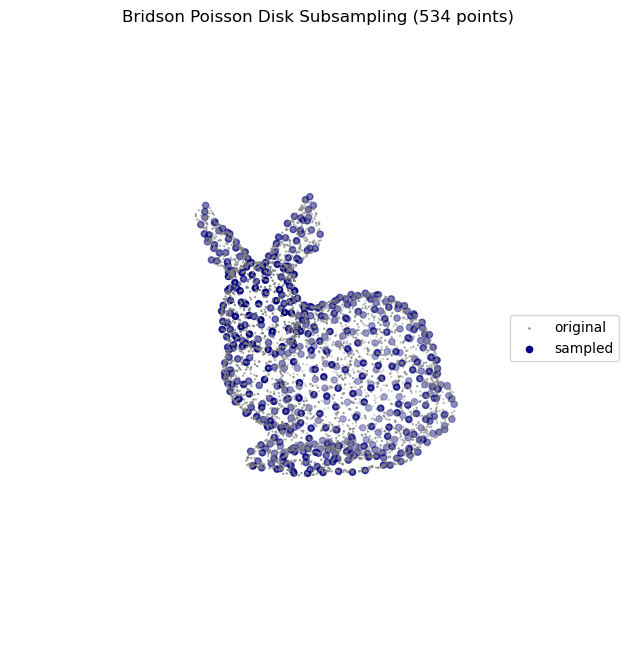

In [20]:
# Poisson Disk Sampling using optimized method
neighbor_finding_function = lambda point, radius: kdtree.query_ball_point(point, radius)
poisson_sampled_indices_opt = poisson_disk_subsample(points, neighbor_finding_function, radius=8., k=30) # Adjust radius to get a similar number of points as before
poisson_sampled_points_opt = points[poisson_sampled_indices_opt]

# Visualize the original and Poisson Disk sampled pointclouds (optimized)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           color='grey', s=0.5, label='original')
ax.scatter(poisson_sampled_points_opt[:, 0], poisson_sampled_points_opt[:, 1],
           poisson_sampled_points_opt[:, 2],
                color="navy", label="sampled")
ax.set_title(f"Bridson Poisson Disk Subsampling ({len(poisson_sampled_points_opt)} points)")
ax.legend(loc="right")
ax.view_init(10, 60)
ax.set_axis_off()
plt.axis("equal")
plt.show()


## Quick comparison

Below is a table summarizing all subsampling techniques discussed in this notebook. Time complexity uses the "big-O notation", where $n$ is the initial number of points and $k$ the desired sample size. The cost of building spatial structures for acceleration is not included in the table but discussed below. $m$ is the total number of voxel cells or octree cells at a given depth.

| Technique       | Category             | Deterministic | Count control | Uniformity | Time complexity  |
|:----------------|:---------------------|:--------------|:--------------|:-----------|:-----------------|
| Random          | Index-based          | No            | Exact         | Low        | $O(k)$ to $O(n)$ |
| Stride          | Index-based          | Yes           | Exact         | Low        | $O(k)$ to $O(n)$ |
| Voxel Grid      | Spatial partitioning | Yes           | Approximate   | Medium     | $O(m)$ to $O(n)$ |
| Octree          | Spatial partitioning | Yes           | Approximate   | Medium     | $O(m)$ to $O(n)$ |
| FPS (naïve)     | Distance-based       | Yes           | Exact         | High       | $O(n k)$         |
| Radius          | Distance-based       | Yes           | Approximate   | Medium     | $O(n \log n)$    |
| Dart throwing   | Distance-based       | No            | Approximate   | Medium     | $O(n)$           |
| Poisson Bridson | Distance-based       | No            | Approximate   | High       | $O(n)$           |

Index‑based techniques are extremely fast. *Random Sampling* runs in linear time either in $k$ when drawing $k$ random indices, or in $n$ when scanning the full array with Bernoulli probability or after generating a random permutation. *Stride Sampling* behaves similarly, with a cost proportional to $k$ when using direct indexing, or $n$ when scanning and retaining every fixed step.

Spatial partitioning methods remain efficient once their structures are built. *Voxel grids* are constructed in linear time, while *octrees* require linear to linearithmic time depending on tree balance. Sampling then simply extracts one representative per voxel or octree leaf, linear time in $m$ occupied cells, or up to linear time in $n$ when selecting the point closest to a cell center.

Distance‑based techniques are more expensive. Naïve *Farthest Point Sampling* updates distances to all $n$ points at each of the $k$ iterations, giving linear time in both $n$ and $k$. *Radius Sampling* uses spatial queries to enforce a minimum spacing, leading to linearithmic time with KD‑trees or grids. *Dart Throwing* with neighbor checks restricted to nearby grid cells may achieve linear time. *Bridson's Poisson Disk Sampling* adds structured candidate generation via an active list and grid, also yielding expected linear behavior.


## Wrapping up

You should now have a better grasp of 3D pointcloud subsampling and its role within the larger processing pipeline. Raw pointclouds often contain millions of points, far more than needed for tasks such as registration, surface reconstruction, semantic segmentation, or real‑time inference. Subsampling is therefore a crucial early step, as it reduces redundancy, controls density, and improves computational tractability while attempting to preserve geometric structure.

Depending on the application, one may choose extremely fast index‑based techniques, spatially aware voxel and octree reductions, or more sophisticated distance‑based techniques that maximize uniformity. No single technique is universally optimal and each represents a specific trade‑off between speed, regularity, determinism, and the ability to target an exact number of samples. Understanding these tradeoffs makes it easier to choose the right technique for downstream algorithms, ensuring that subsequent stages operate efficiently without sacrificing essential geometric information.